In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
import os
import warnings


warnings.filterwarnings('ignore')

# 1. Load the Trained Model
model_path = "../03_Models/01_XGB_Model.json"
model = xgb.XGBClassifier()
model.load_model(model_path)
print(f"✅ Model successfully loaded from: {model_path}")

# 2. Load the Training Data
df = pd.read_csv("../02_Processed_Data/06_Training_Data.csv")

# Ensure feature columns exactly match the training phase
feature_columns = [
    'IMotor_std', 'Z_Accel_std', 'VibRes_Accel_std', 'Trq_std',
    'Z_HighFreq_RMS', 'IMotor_HighFreq_RMS', 'Trq_HighFreq_RMS',
    'IMotor_std_Ratio_to_Past', 'Z_Accel_std_Ratio_to_Past', 
    'VibRes_Accel_std_Ratio_to_Past', 'Trq_std_Ratio_to_Past', 
    'IMotor_HighFreq_RMS_Ratio_to_Past', 'Z_HighFreq_RMS_Ratio_to_Past',
    'IMotor_std_Trend', 'Z_Accel_std_Trend', 'VibRes_Accel_std_Trend',
    'Trq_std_Trend', 'IMotor_HighFreq_RMS_Trend', 'Z_HighFreq_RMS_Trend'
]

X = df[feature_columns]
y = df['chatter']

print(f"✅ Data loaded. Ready for SHAP analysis with {X.shape[0]} samples and {X.shape[1]} features.")

✅ Model successfully loaded from: ../03_Models/01_XGB_Model.json
✅ Data loaded. Ready for SHAP analysis with 25307 samples and 19 features.


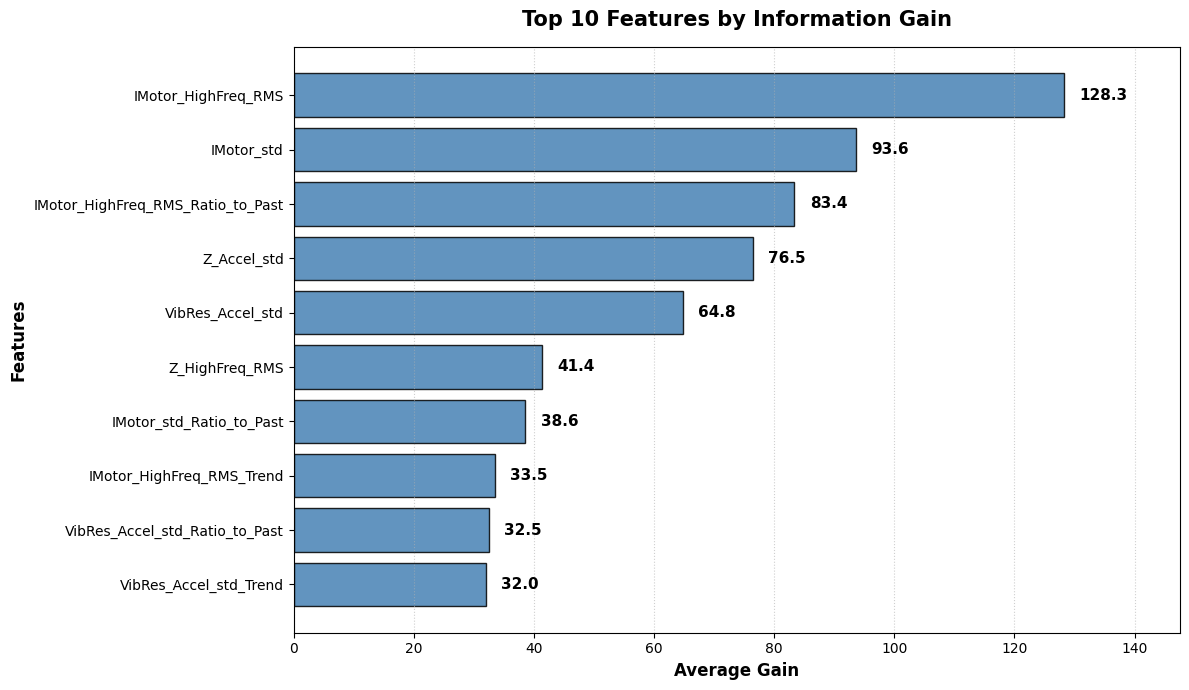

In [2]:
# --- A. GLOBAL FEATURE IMPORTANCE (XGBOOST GAIN) ---

# 1. Get the importance dictionary from the model (Gain type)
importance_dict = model.get_booster().get_score(importance_type='gain')

# 2. Convert to a DataFrame, sort, and get the Top 10
df_importance = pd.DataFrame(list(importance_dict.items()), columns=['Feature', 'Gain'])
df_importance = df_importance.sort_values(by='Gain', ascending=True).tail(10)

# 3. Create the plot
plt.figure(figsize=(12, 7))
bars = plt.barh(df_importance['Feature'], df_importance['Gain'], color='steelblue', edgecolor='black', alpha=0.85)

# 4. Add clean, formatted text labels to the bars
for bar in bars:
    width = bar.get_width()
    # Add the value text slightly to the right of the bar, rounded to 1 decimal
    plt.text(width + (df_importance['Gain'].max() * 0.02),  
             bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}', 
             va='center', fontweight='bold', fontsize=11)

# 5. Professional Formatting
plt.title('Top 10 Features by Information Gain', fontweight='bold', fontsize=15, pad=15)
plt.xlabel('Average Gain', fontweight='bold', fontsize=12)
plt.ylabel('Features', fontweight='bold', fontsize=12)

# Dynamically extend the x-axis limit by 15% so the text never gets cut off
plt.xlim(0, df_importance['Gain'].max() * 1.15) 

plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

🚀 Calculating SHAP values... (This might take a few seconds)
✅ SHAP calculations completed. Generating plot...


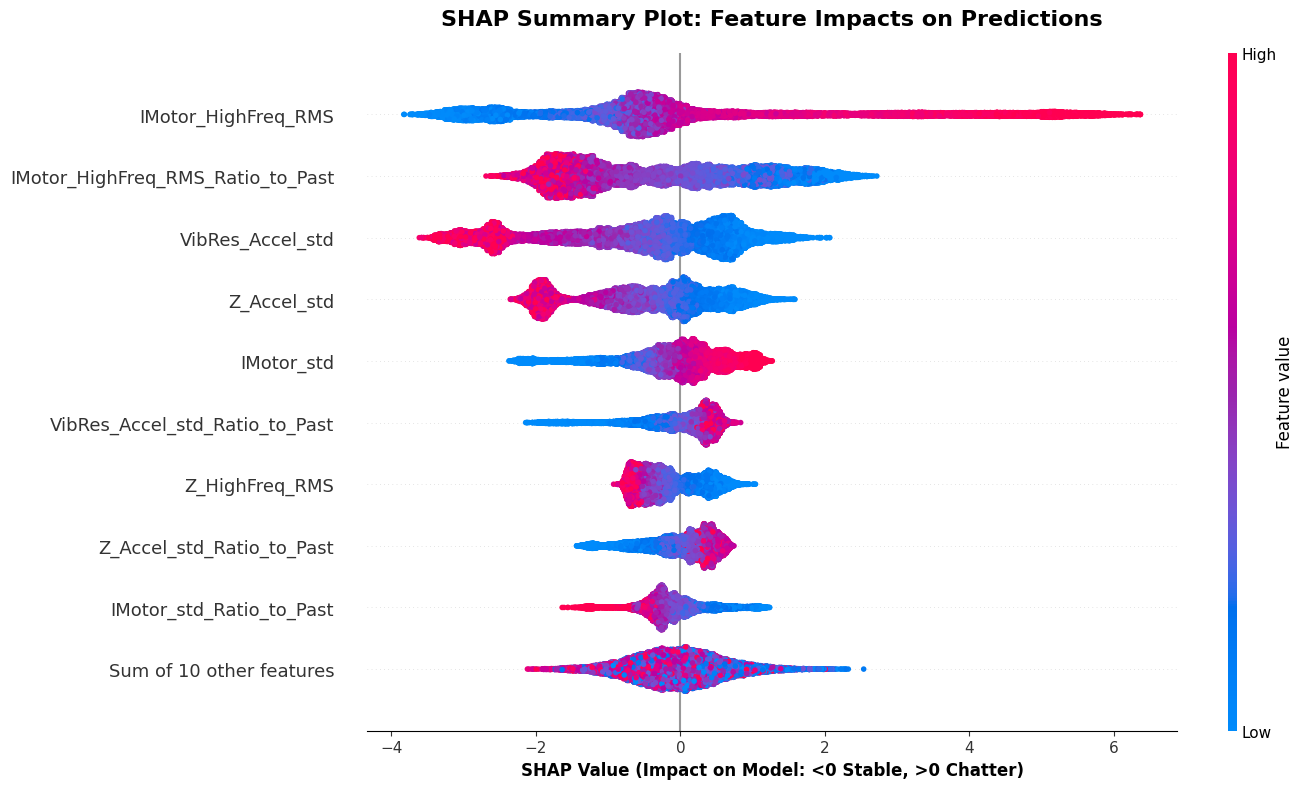

In [3]:
# --- B. SHAP BEESWARM PLOT (GLOBAL EXPLAINABILITY) ---
print("🚀 Calculating SHAP values... (This might take a few seconds)")

# Initialize the SHAP Tree Explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer(X)

print("✅ SHAP calculations completed. Generating plot...")


plt.figure(figsize=(14, 8)) 


shap.plots.beeswarm(shap_values, max_display=10, plot_size=(14, 8), show=False)

# Professional Formatting for Thesis
plt.title('SHAP Summary Plot: Feature Impacts on Predictions', fontweight='bold', fontsize=16, pad=20)
plt.xlabel('SHAP Value (Impact on Model: <0 Stable, >0 Chatter)', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

📊 Generating Dependence Plot for: IMotor_HighFreq_RMS


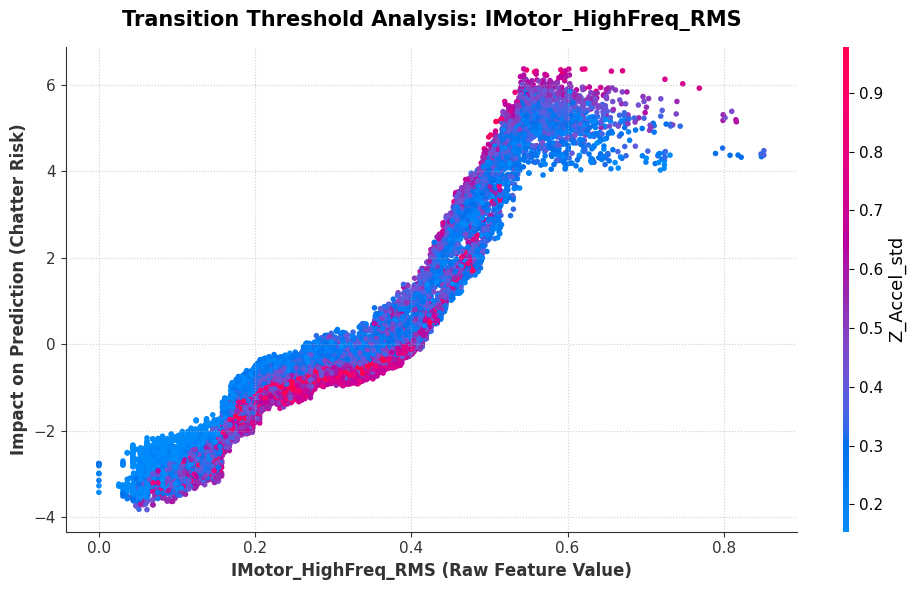

In [4]:
# --- C. SHAP DEPENDENCE PLOT (FEATURE INTERACTION) ---

top_feature_name = 'IMotor_HighFreq_RMS'

print(f"📊 Generating Dependence Plot for: {top_feature_name}")


fig, ax = plt.subplots(figsize=(10, 6))


shap.dependence_plot(
    top_feature_name, 
    shap_values.values, 
    X, 
    show=False,
    ax=ax 
)


plt.ylabel("Impact on Prediction (Chatter Risk)", fontweight='bold', fontsize=12)


plt.xlabel(f"{top_feature_name} (Raw Feature Value)", fontweight='bold', fontsize=12)


plt.title(f"Transition Threshold Analysis: {top_feature_name}", fontweight='bold', fontsize=15, pad=15)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


🔍 1. ANALYSIS FOR A STABLE (0) INSTANCE


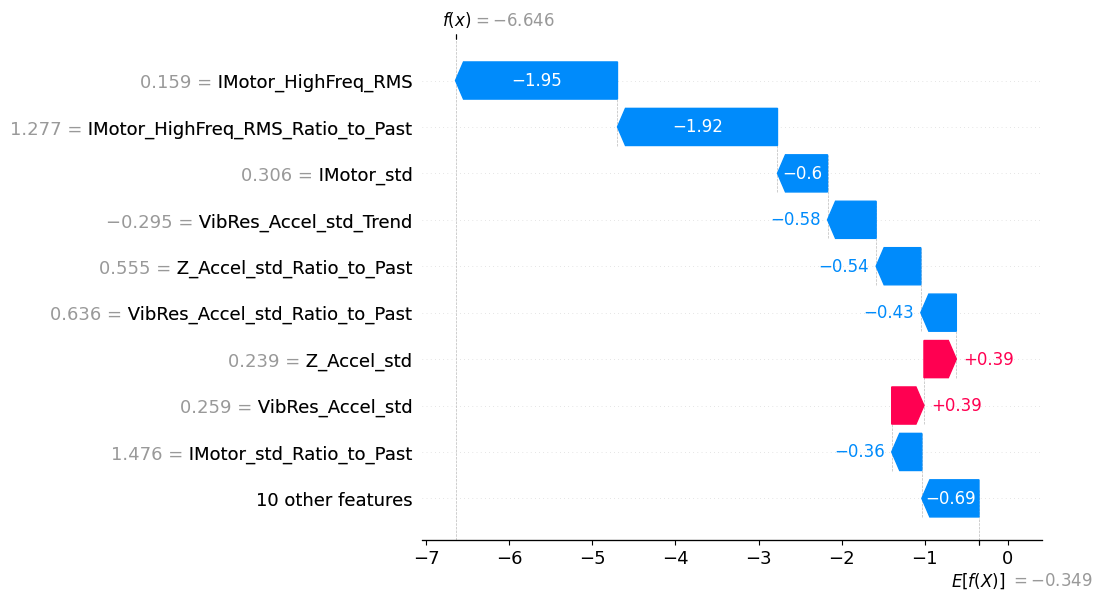


🚨 2. ANALYSIS FOR A CHATTER (1) INSTANCE


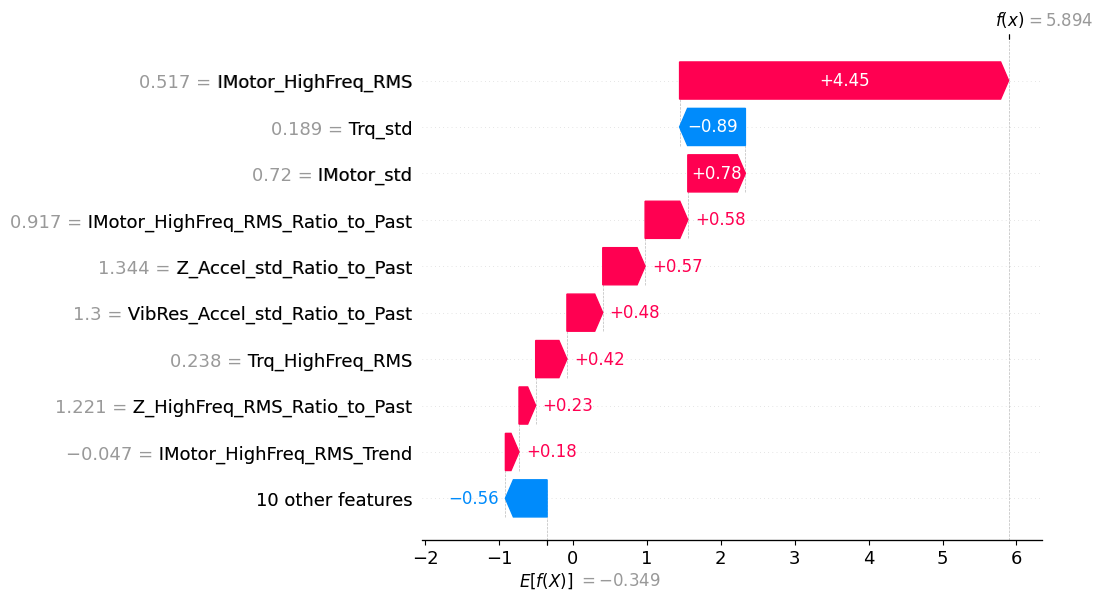

In [5]:
# --- D. LOCAL EXPLAINABILITY (WATERFALL PLOT) ---

# Find indices for one Stable instance and one Chatter instance to analyze
stable_idx = y[y == 0].index[100] # Selecting a random stable sample
chatter_idx = y[y == 1].index[100] # Selecting a random chatter sample

print("\n" + "="*50)
print("🔍 1. ANALYSIS FOR A STABLE (0) INSTANCE")
print("="*50)
# Plot the waterfall for the stable instance
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[stable_idx], max_display=10)


print("\n" + "="*50)
print("🚨 2. ANALYSIS FOR A CHATTER (1) INSTANCE")
print("="*50)
# Plot the waterfall for the chatter instance
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[chatter_idx], max_display=10)